In [49]:
using Revise
includet("functions.jl")
using .MyFunctions

using LinearAlgebra
using QuantumToolbox
using ProgressMeter
using CairoMakie

CairoMakie.activate!(type = "png", px_per_unit = 2)

set_theme!(merge(theme_latexfonts(),
    Theme(
        size           = (800, 500),
        fontsize       = 20,
        figure_padding = 14,
        Axis = (
            xgridvisible = false,
            ygridvisible = false,
            xtickalign   = 0,
            ytickalign   = 0,
            xlabelsize     = 24,
            ylabelsize     = 24,
            xticklabelsize = 20,
            yticklabelsize = 20,
        ),
        Lines = (linewidth = 3,),
    ),
))

# Hermitian case

## $N=1$ qubit

In [50]:
ωa = 1.0
ωb = 1.0
Nc = 20
N = 1

vars = (ωa=ωa, ωb=ωb, Nc=Nc, N=N);

In [51]:
g_list = range(1e-3, 1.5, 600) |> collect

neigs = 40

vals_full = similar(g_list, length(g_list), neigs)
fill!(vals_full, NaN)

Prog = Progress(length(g_list))
@time Threads.@threads for i in eachindex(g_list)
    vals_full[i,:] = get_shifted_eigvals(H_Dicke(g_list[i], vars), neigs, -1000, 1e-16)
    next!(Prog)
end

nel = 4    # eigenvalues kept per block, (N+3-2*j)*nel
nj = Int64(floor(N/2+1))
neigs = [Int64((N+1-2*i)*nel) for i in 0:nj-1]
vals_sep = similar(g_list, nj, length(g_list), maximum(neigs))
fill!(vals_sep, NaN)

H_0_sep, H_int_sep = H_comp_separated(vars)
@time Threads.@threads for i in eachindex(g_list)
    H_Dicke = H_Dicke_separated(H_0_sep, H_int_sep, g_list[i])
    for j in 1:nj
        neigs_j = neigs[j]
        prov = eigsolve(H_Dicke[j], eigvals=neigs_j, sigma=-1000, tol=1e-16)
        vals_sep[j,i,1:neigs_j] .= real.(prov.values)
    end
end

vals_polaron = similar(g_list, nj, length(g_list), maximum(neigs))
fill!(vals_polaron, NaN)

@time Threads.@threads for i in eachindex(g_list)
    for j in 1:nj
        neigs_j = neigs[j]
        prov = eigsolve(H_Dicke_polaron(g_list[i], vars)[j], eigvals=neigs_j, sigma=-1000, tol=1e-16)
        vals_polaron[j,i,1:neigs_j] .= real.(prov.values)
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03


  3.278703 seconds (4.63 M allocations: 544.129 MiB, 31.49% gc time, 1 lock conflict, 48.89% compilation time: 97% of which was recompilation)
  1.203412 seconds (720.96 k allocations: 552.955 MiB, 7.40% gc time, 5.66% compilation time: 8% of which was recompilation)
  1.212577 seconds (475.58 k allocations: 742.837 MiB, 8.33% gc time, 4.77% compilation time)


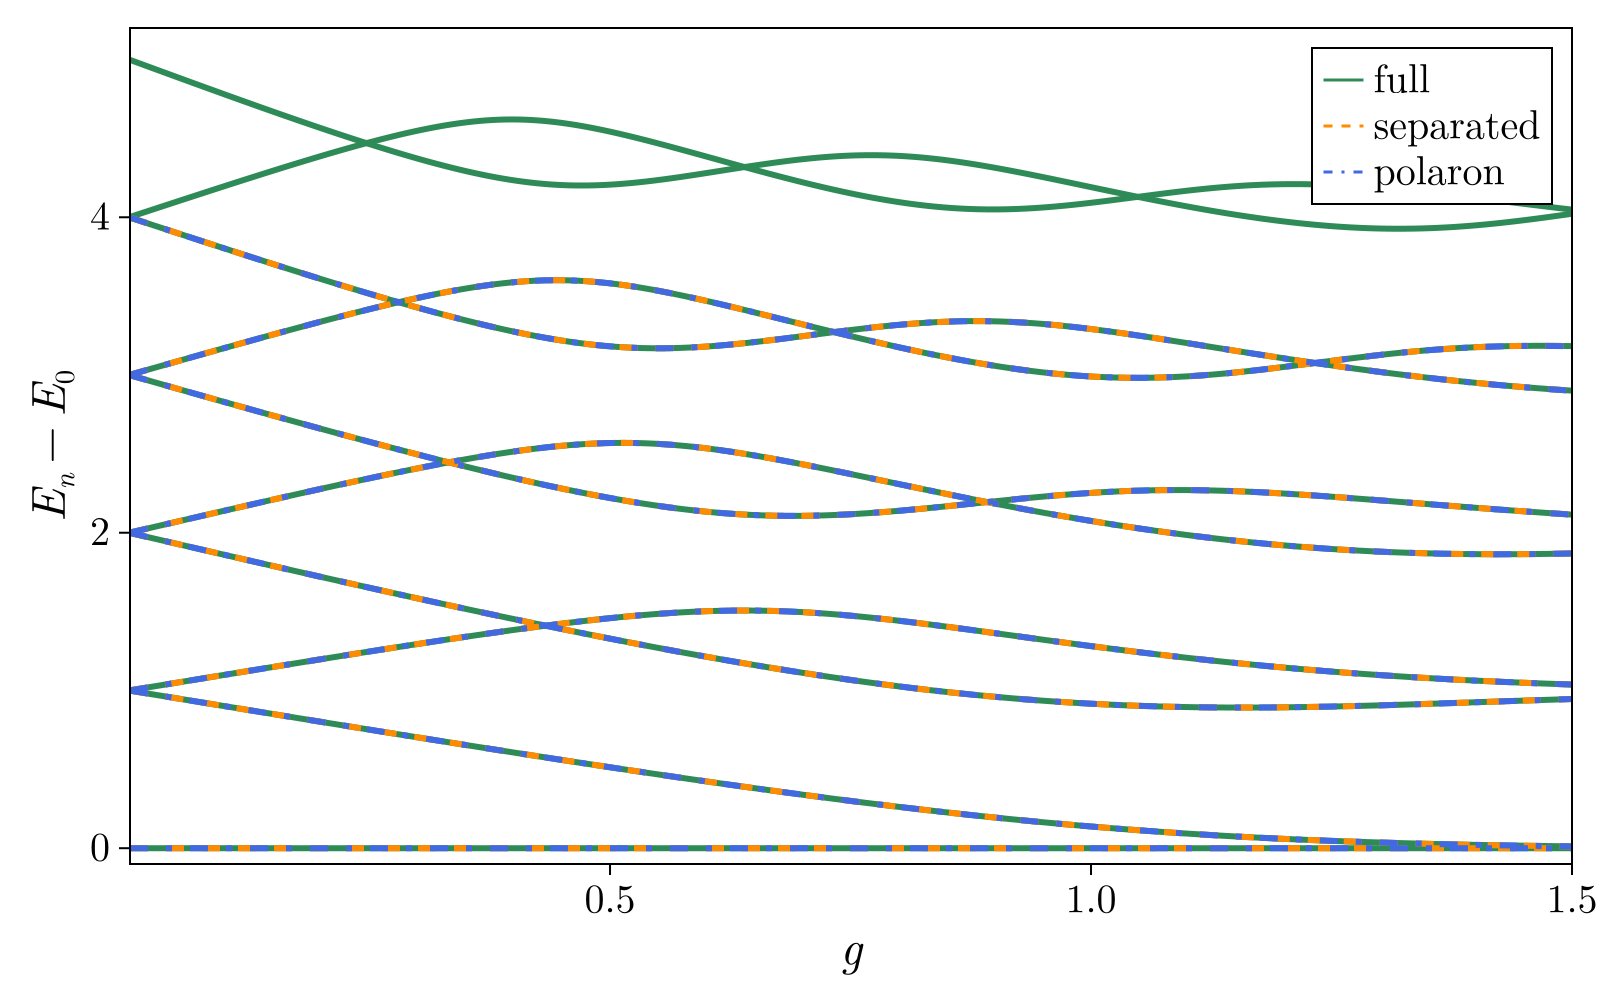

In [52]:
fig = Figure()
ax = Axis(fig[1, 1]; xlabel = L"g", ylabel = L"E_n - E_0", limits = ((g_list[1], g_list[end]), (-0.1, 5.2)))

for i in 1:10
    lines!(ax, g_list, vals_full[:, i]; color = :seagreen)
end

for i in 1:nj
    for k in axes(vals_sep, 3)
        lines!(ax, g_list, vals_sep[i, :, k] .- vals_sep[1, :, 1]; color = :darkorange, linestyle = :dash)
    end
    for k in axes(vals_polaron, 3)
        lines!(ax, g_list, vals_polaron[i, :, k] .- vals_polaron[1, :, 1]; color = :royalblue, linestyle = :dashdot)
    end
end

Legend(fig[1, 1],
    [LineElement(color = :seagreen),
     LineElement(color = :darkorange, linestyle = :dash),
     LineElement(color = :royalblue, linestyle = :dashdot)],
    ["full", "separated", "polaron"];
    tellwidth = false, tellheight = false,
    halign = :right, valign = :top, margin = (10, 10, 10, 10)
)

# save("QRM_energies_1at.pdf", fig; px_per_unit = 3)
fig

## $N=2$ qubits

In [ ]:
ωa = 1.0
ωb = 1.0
Nc = 20
N = 2

vars = (ωa=ωa, ωb=ωb, Nc=Nc, N=N);

In [29]:
g_list = range(1e-3, 3, 200) |> collect

neigs = 40

vals_full = similar(g_list, length(g_list), neigs)
fill!(vals_full, NaN)

Prog = Progress(length(g_list))
@time Threads.@threads for i in eachindex(g_list)
    vals_full[i,:] = get_shifted_eigvals(H_Dicke(g_list[i], vars), neigs, -1000, 1e-16)
    next!(Prog)
end

nel = 4    # eigenvalues kept per block, (N+3-2*j)*nel
nj = Int64(floor(N/2+1))
neigs = [Int64((N+1-2*i)*nel) for i in 0:nj-1]
vals_sep = similar(g_list, nj, length(g_list), maximum(neigs))
fill!(vals_sep, NaN)

H_0_sep, H_int_sep = H_comp_separated(vars)
@time Threads.@threads for i in eachindex(g_list)
    H_Dicke = H_Dicke_separated(H_0_sep, H_int_sep, g_list[i])
    for j in 1:nj
        neigs_j = neigs[j]
        prov = eigsolve(H_Dicke[j], eigvals=neigs_j, sigma=-1000, tol=1e-16)
        vals_sep[j,i,1:neigs_j] .= real.(prov.values)
    end
end

vals_polaron = similar(g_list, nj, length(g_list), maximum(neigs))
fill!(vals_polaron, NaN)

@time Threads.@threads for i in eachindex(g_list)
    for j in 1:nj
        neigs_j = neigs[j]
        prov = eigsolve(H_Dicke_polaron(g_list[i], vars)[j], eigvals=neigs_j, sigma=-1000, tol=1e-16)
        vals_polaron[j,i,1:neigs_j] .= real.(prov.values)
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03


  3.515982 seconds (1.79 M allocations: 379.016 MiB, 1.89% gc time, 14.98% compilation time)
  1.075486 seconds (514.05 k allocations: 393.639 MiB, 6.36% gc time, 5.10% compilation time)
  1.035304 seconds (398.49 k allocations: 633.836 MiB, 8.03% gc time, 5.06% compilation time)


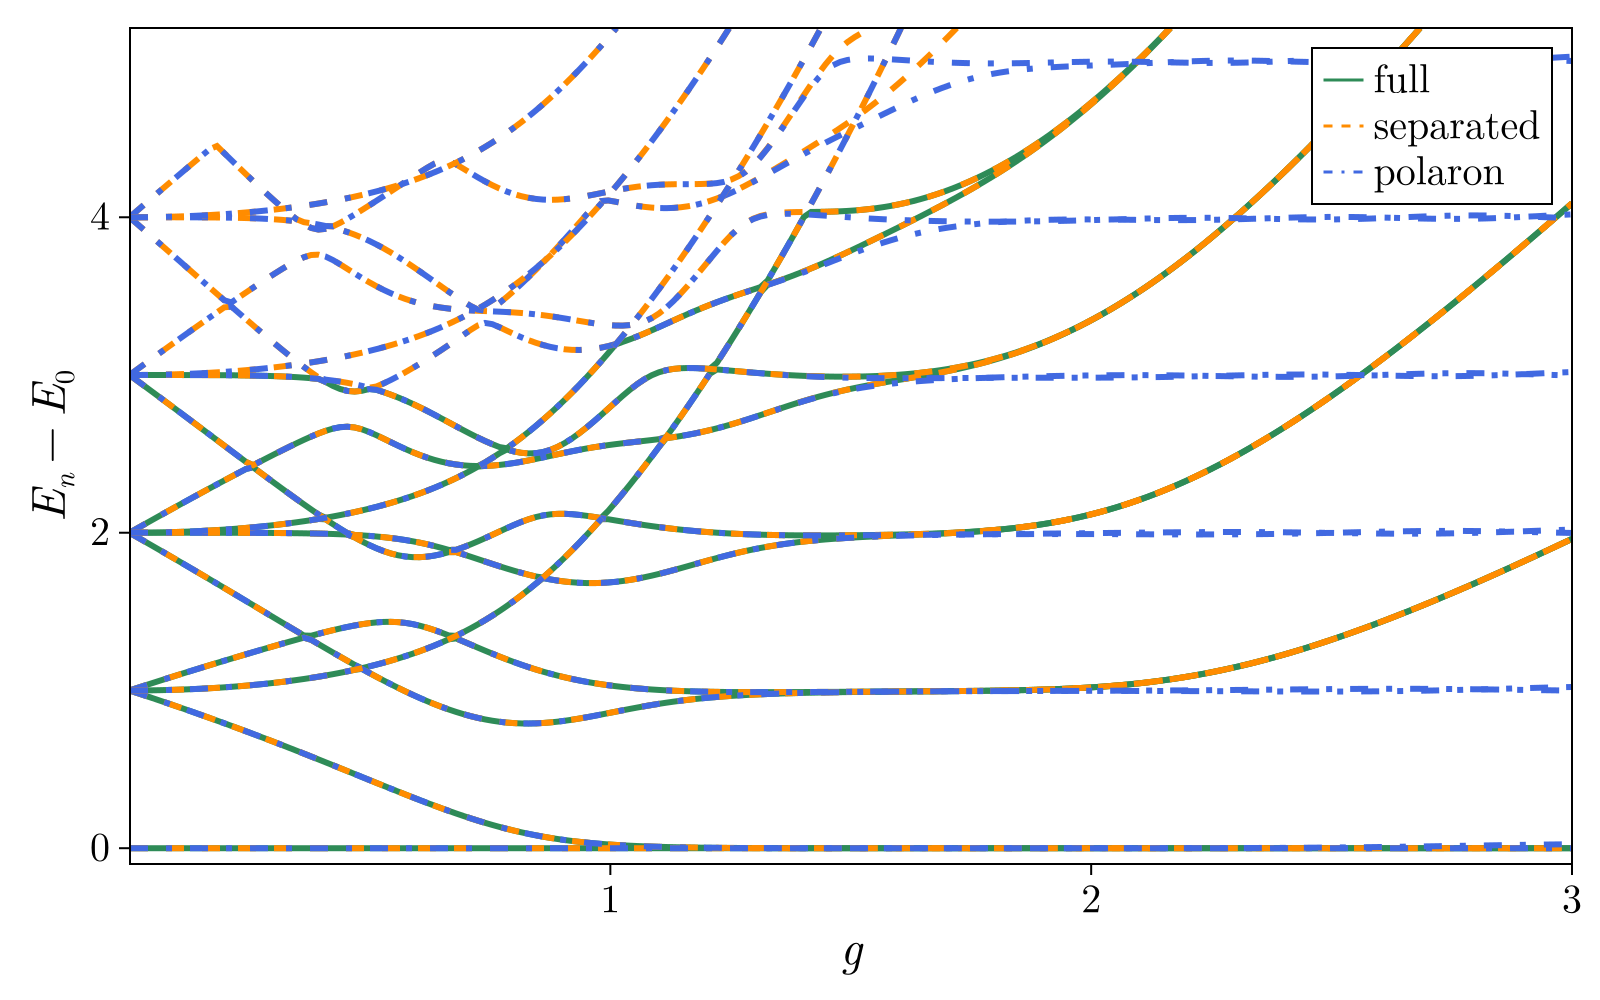

In [31]:
fig = Figure()
ax = Axis(fig[1, 1]; xlabel = L"g", ylabel = L"E_n - E_0", limits = ((g_list[1], g_list[end]), (-0.1, 5.2)))

for i in 1:10
    lines!(ax, g_list, vals_full[:, i]; color = :seagreen)
end

for i in 1:nj
    for k in axes(vals_sep, 3)
        lines!(ax, g_list, vals_sep[i, :, k] .- vals_sep[1, :, 1]; color = :darkorange, linestyle = :dash)
    end
    for k in axes(vals_polaron, 3)
        lines!(ax, g_list, vals_polaron[i, :, k] .- vals_polaron[1, :, 1]; color = :royalblue, linestyle = :dashdot)
    end
end

Legend(fig[1, 1],
    [LineElement(color = :seagreen),
     LineElement(color = :darkorange, linestyle = :dash),
     LineElement(color = :royalblue, linestyle = :dashdot)],
    ["full", "separated", "polaron"];
    tellwidth = false, tellheight = false,
    halign = :right, valign = :top, margin = (10, 10, 10, 10)
)

save("QRM_energies_2at.pdf", fig; px_per_unit = 3)
fig

# Non-Hermitian case

## $N=1$ qubit

In [53]:
P_NH = (g = 1.0, ωa = 1.0, ωb = 1.0, Nc = 80, N = 1, γa = 0.0, γb = 0.0)

_vars(p) = (ωa = p.ωa, ωb = p.ωb, Nc = p.Nc, N = p.N, γa = p.γa, γb = p.γb)
nh_block(p, wh) = (r = parity_blocks_NH(p.g, _vars(p)); wh === :even ? r[1] : r[2])
withp(p; kw...) = merge(p, (; kw...))
set2(p, k1, x1, k2, x2) = merge(p, NamedTuple{(k1, k2)}((x1, x2)))

function pair_gap_overlap(H; kmax = 10)
    F = eigen(H)
    idx = sortperm(real.(F.values))
    vals = F.values[idx]
    vecs = F.vectors[:, idx]
    
    k = min(kmax, length(vals))
    m = Inf
    pa = 0
    pb = 0
    for a in 1:k, b in a+1:k
        d = abs(vals[a] - vals[b])
        d < m && (m = d; pa = a; pb = b)
    end
    return m, abs(dot(vecs[:, pa], vecs[:, pb])) / (norm(vecs[:, pa]) * norm(vecs[:, pb]))
end

function closest_pair(p, wh; kmax = 10)
    v = sort(eigvals(nh_block(p, wh)), by = real)

    k = min(kmax, length(v))
    m = Inf
    pa = 0
    pb = 0
    for a in 1:k, b in a+1:k
        d = abs(v[a] - v[b])
        d < m && (m = d; pa = a; pb = b)
    end
    return pa, pb
end

d2_pair(p, k1, k2, x1, x2, wh, pa, pb) = (v = sort(eigvals(nh_block(set2(p, k1, x1, k2, x2), wh)), by = real); (v[pa] - v[pb])^2)

function newton_ep(p, k1, k2, wh, pa, pb; iters = 60, step = 1e-6)
    x = [getfield(p, k1), getfield(p, k2)]
    for _ in 1:iters
        f  = d2_pair(p, k1, k2, x[1], x[2], wh, pa, pb)
        f1 = (d2_pair(p, k1, k2, x[1]+step, x[2], wh, pa, pb) - f) / step
        f2 = (d2_pair(p, k1, k2, x[1], x[2]+step, wh, pa, pb) - f) / step
        dx = [real(f1) real(f2); imag(f1) imag(f2)] \ [-real(f); -imag(f)]
        s  = min(1.0, 0.3 / (norm(dx) + step^2))
        x .+= s .* dx
        x[1] = clamp(x[1], 0.0, 3.0); x[2] = clamp(x[2], 0.0, 3.0)
        norm(s .* dx) < 1e-13 && break
    end
    return set2(p, k1, x[1], k2, x[2])
end

function ep_check(p, wh, pa, pb)
    F = eigen(nh_block(p, wh))
    idx = sortperm(real.(F.values))
    vals = F.values[idx]
    vecs = F.vectors[:, idx]
    gap = abs(vals[pa] - vals[pb])
    ov  = abs(dot(vecs[:, pa], vecs[:, pb])) / (norm(vecs[:, pa]) * norm(vecs[:, pb]))
    return gap, ov
end

ep_check (generic function with 1 method)

In [ ]:
gs = range(0.2, 1.5, 200) |> collect
γs = range(0.05, 1.0, 200) |> collect

GAP = fill(Inf, length(gs), length(γs))
OVL = zeros(length(gs), length(γs))
PAR = fill(:even, length(gs), length(γs))

Prog = Progress(length(gs))
@time Threads.@threads for (i, g) in enumerate(gs), (j, γa) in enumerate(γs)
    He, Ho = parity_blocks_NH(g, _vars(withp(P_NH; g = g, γa = γa)))
    me, oe = pair_gap_overlap(He)
    mo, oo = pair_gap_overlap(Ho)
    if me <= mo
        GAP[i, j] = me
        OVL[i, j] = oe
        PAR[i, j] = :even
    else
        GAP[i, j] = mo
        OVL[i, j] = oo
        PAR[i, j] = :odd
    end
end

eps_found = NamedTuple[]
@time Threads.@threads for i in 2:length(gs)-1, j in 2:length(γs)-1
    if all(GAP[i, j] <= GAP[i+di, j+dj] for di in -1:1, dj in -1:1)
        wh = PAR[i, j]
        pseed = withp(P_NH; g = gs[i], γa = γs[j])
        pa, pb = closest_pair(pseed, wh)
        pe = newton_ep(pseed, :g, :γa, wh, pa, pb)
        gap, ov = ep_check(pe, wh, pa, pb)
        if gap < 1e-5 && ov > 1 - 1e-6
            e = (g = round(pe.g, digits = 4), γa = round(pe.γa, digits = 4), parity = wh, gap = gap, ov = ov, energy_levels = (pa, pb))
            any(u -> abs(u.g - e.g) < 1e-2 && abs(u.γa - e.γa) < 1e-2, eps_found) || push!(eps_found, e)
        end
    end
end

println("exact EPs found (γb = $(P_NH.γb)): ", length(eps_found))
foreach(e -> println("  g = ", e.g, "   γa = ", e.γa, "   ", e.parity, "   ", e.energy_levels, "   gap = ", round(e.gap, sigdigits = 2), "   1-overlap = ", round(1 - e.ov, sigdigits = 2)), eps_found)

exact EPs found (γb = 0.0): 26
  g = 0.3552   γa = 0.5832   even   (9, 10)   gap = 2.1e-7   1-overlap = 3.8e-14
  g = 0.377   γa = 0.5833   odd   (8, 9)   gap = 1.2e-7   1-overlap = 1.4e-14
  g = 0.4033   γa = 0.5834   even   (7, 8)   gap = 1.3e-7   1-overlap = 1.6e-14
  g = 0.4361   γa = 0.5835   odd   (6, 7)   gap = 2.1e-7   1-overlap = 3.8e-14
  g = 0.4787   γa = 0.5838   even   (5, 6)   gap = 1.7e-7   1-overlap = 2.7e-14
  g = 0.5372   γa = 0.5843   odd   (4, 5)   gap = 1.1e-7   1-overlap = 1.0e-14
  g = 0.6169   γa = 0.4099   odd   (9, 10)   gap = 2.2e-7   1-overlap = 3.1e-14
  g = 0.6256   γa = 0.5855   even   (3, 4)   gap = 9.2e-8   1-overlap = 7.3e-15
  g = 0.6555   γa = 0.4103   even   (8, 9)   gap = 1.8e-7   1-overlap = 2.1e-14
  g = 0.7027   γa = 0.4109   odd   (7, 8)   gap = 1.7e-7   1-overlap = 1.9e-14
  g = 0.7622   γa = 0.4119   even   (6, 7)   gap = 9.6e-8   1-overlap = 5.9e-15
  g = 0.7875   γa = 0.5898   odd   (2, 3)   gap = 8.7e-8   1-overlap = 6.1e-15
  g = 0.8411  

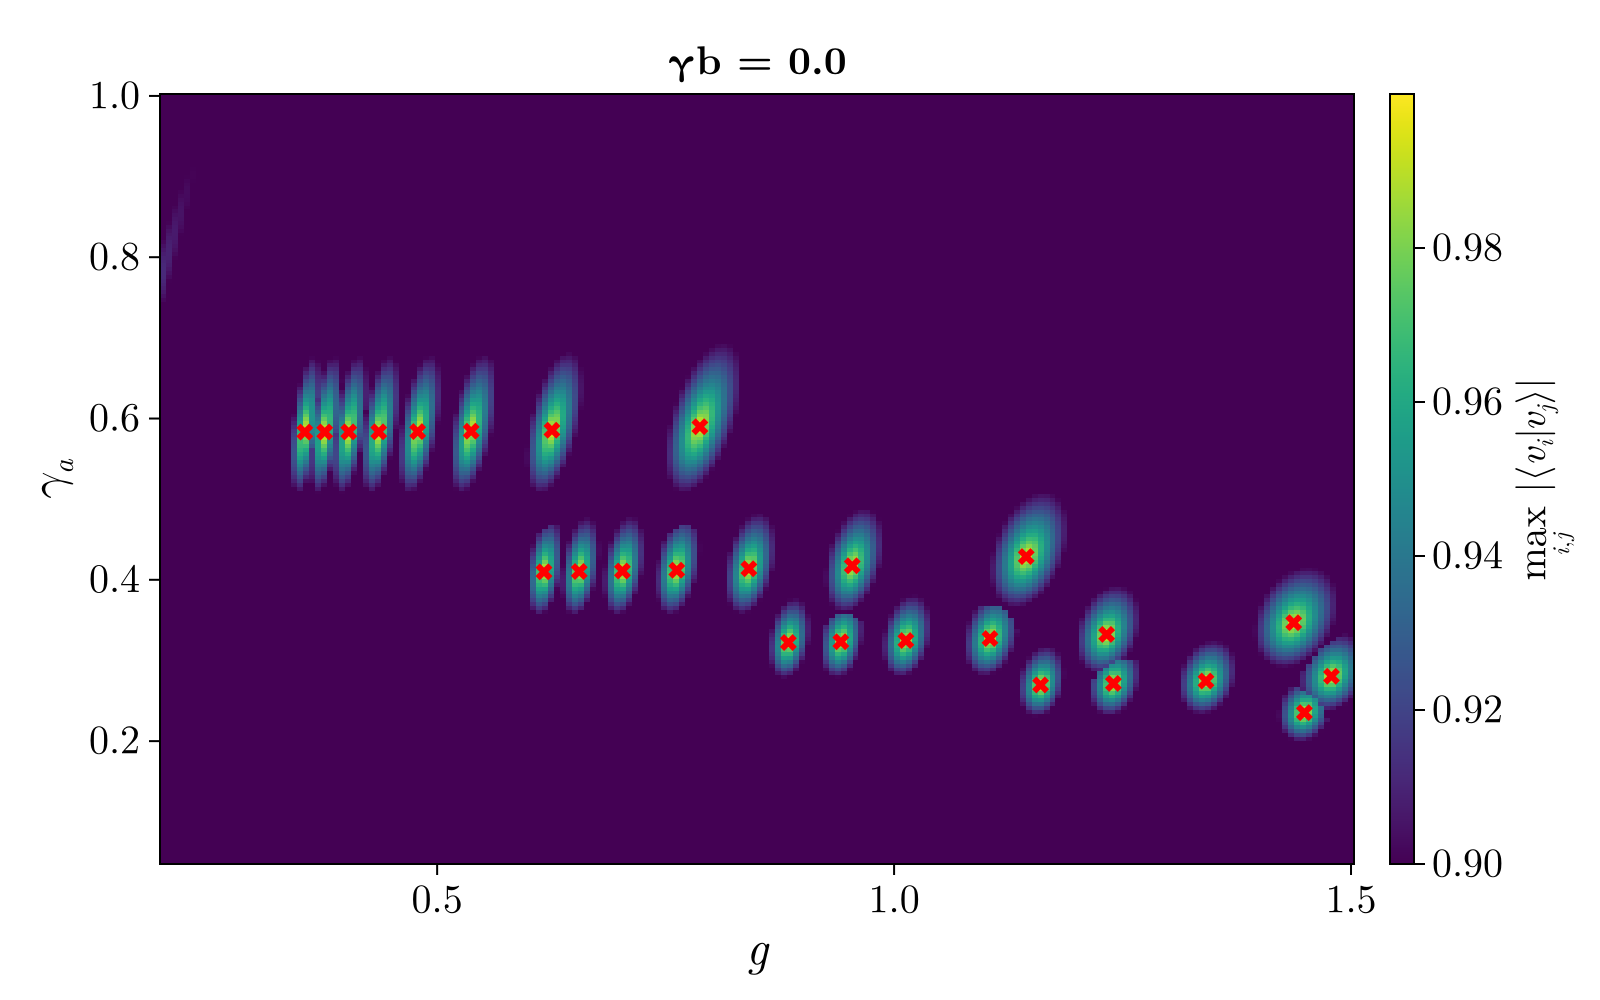

In [54]:
# Map of the eigenvector overlap over (g, γa), with the exact EPs marked
fig_map = Figure(size = (800, 500))
ax = Axis(fig_map[1, 1]; xlabel = L"g", ylabel = L"\gamma_a", title = "γb = $(P_NH.γb)")
hm = heatmap!(ax, gs, γs, OVL; colormap = :viridis, colorrange = (0.9, 1.0))
Colorbar(fig_map[1, 2], hm; label = L"\max_{i,j}\,|\langle v_i|v_j\rangle|")
scatter!(ax, [e.g for e in eps_found], [e.γa for e in eps_found];
         color = :red, marker = :xcross, markersize = 12)
# save("ep_map.png", fig_map; px_per_unit = 3)
fig_map

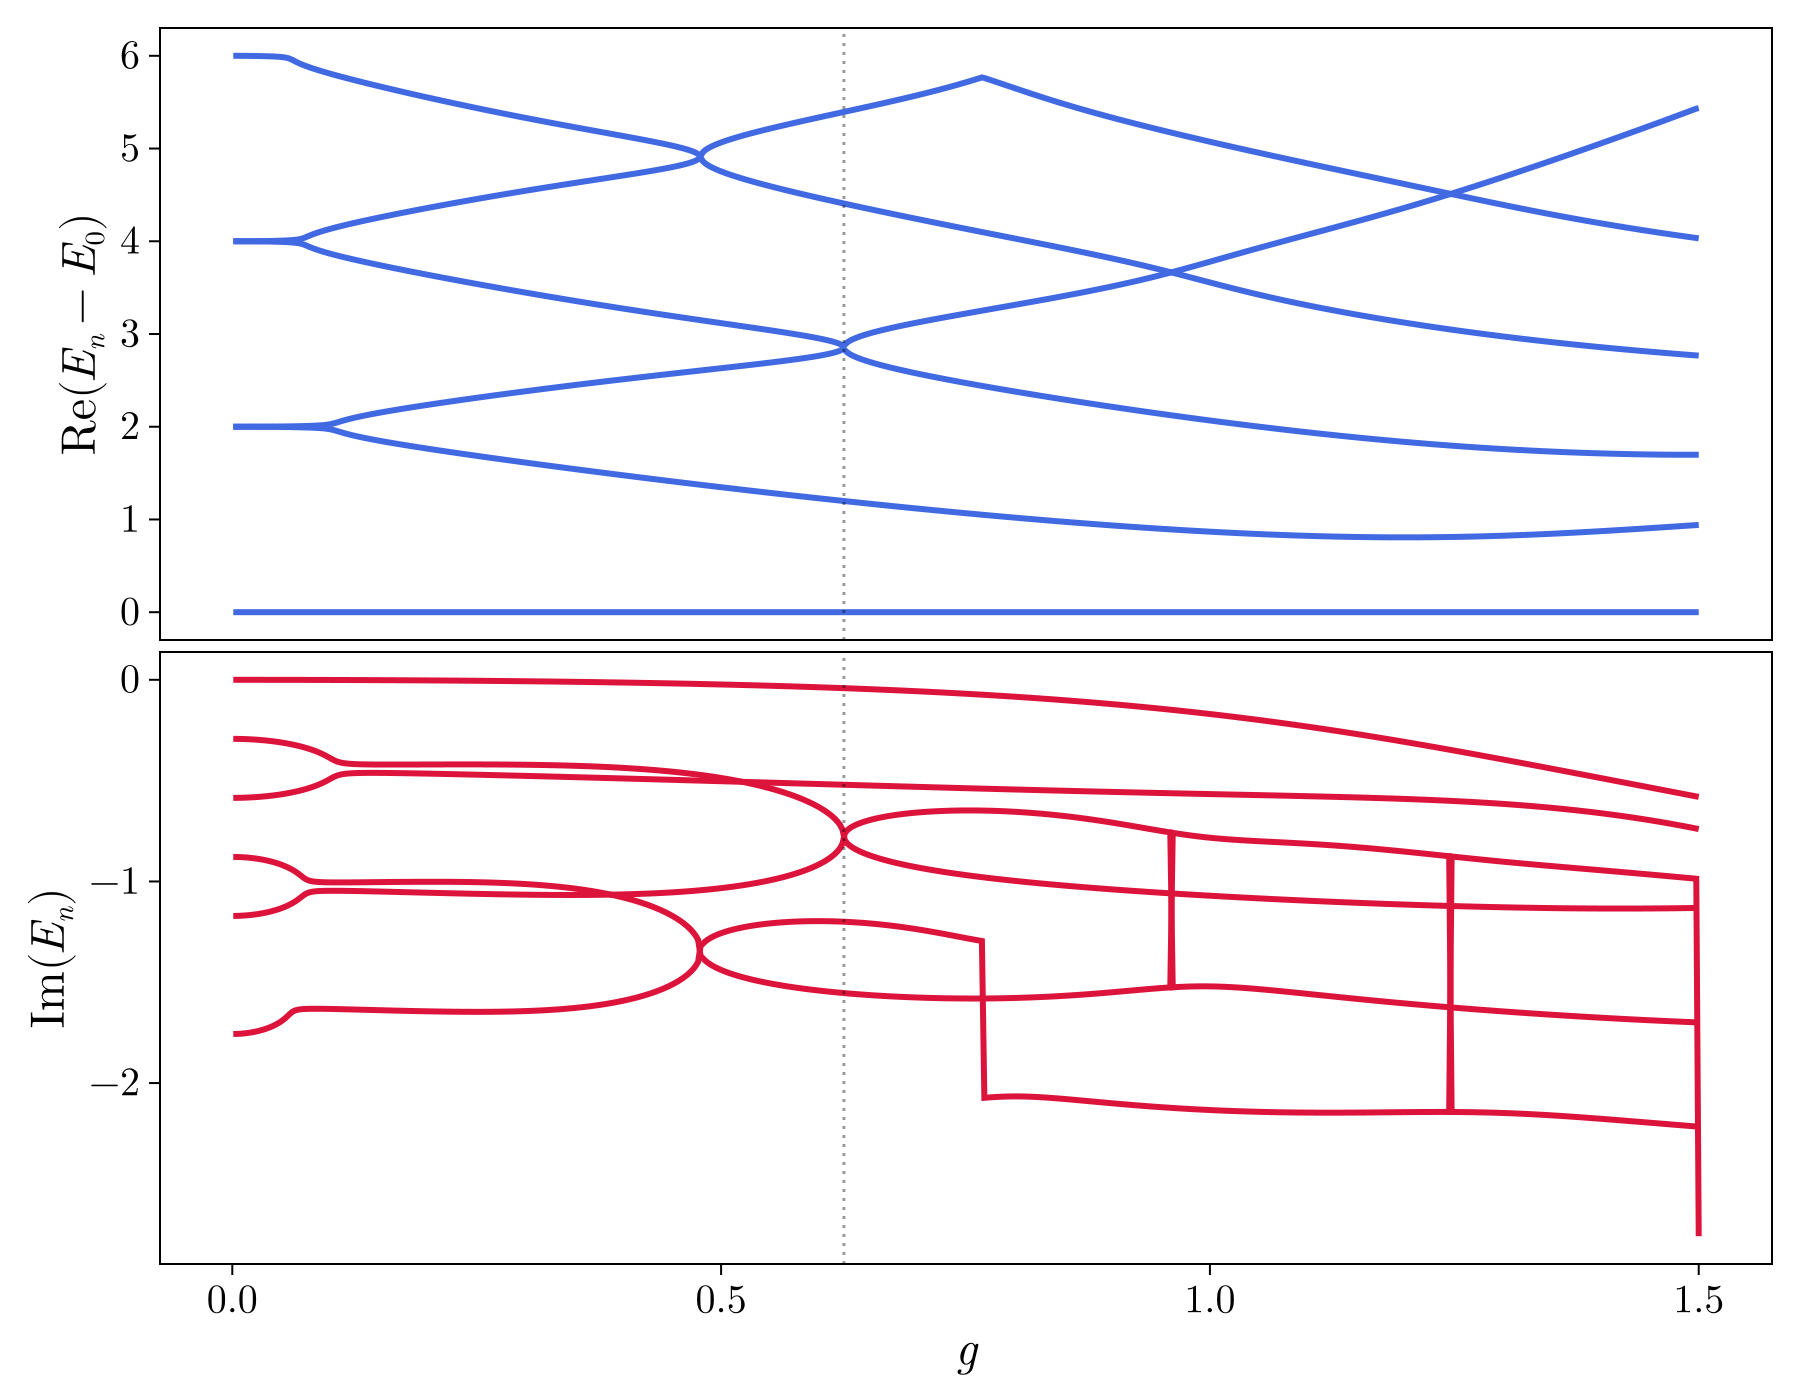

In [ ]:
# Spectrum cut through one exact EP: fix all parameters except g and scan g across the EP
ep  = eps_found[8]
pep = withp(P_NH; g = ep.g, γa = ep.γa)
g_list_cut  = range(ep.g - 0.15, ep.g + 0.15, 400) |> collect
pa, pb = ep.energy_levels
kshow = 6

Ecut = fill(NaN + 0im, length(g_list), kshow)
for (i, g) in enumerate(g_list)
    v = sort(eigvals(nh_block(withp(pep; g = g), ep.parity)), by = real)
    Ecut[i, :] = v[1:kshow] .- real(v[1])
end


fig_cut = Figure(size = (900, 700))

a1 = Axis(fig_cut[1, 1]; ylabel = L"\mathrm{Re}(E_n - E_0)")
for n in 1:kshow
    lines!(a1, g_list, real.(Ecut[:, n]); color = :royalblue)
end

a2 = Axis(fig_cut[2, 1]; xlabel = L"g", ylabel = L"\mathrm{Im}(E_n)")
for n in 1:kshow
    lines!(a2, g_list, imag.(Ecut[:, n]); color = :crimson)
end

hidexdecorations!(a1; grid = false)
linkxaxes!(a1, a2)
vlines!(a1, [ep.g]; color = (:black, 0.4), linestyle = :dot)
vlines!(a2, [ep.g]; color = (:black, 0.4), linestyle = :dot)
rowgap!(fig_cut.layout, 6)
# save("spectrum_cut_EP.png", fig_cut; px_per_unit = 3)
fig_cut

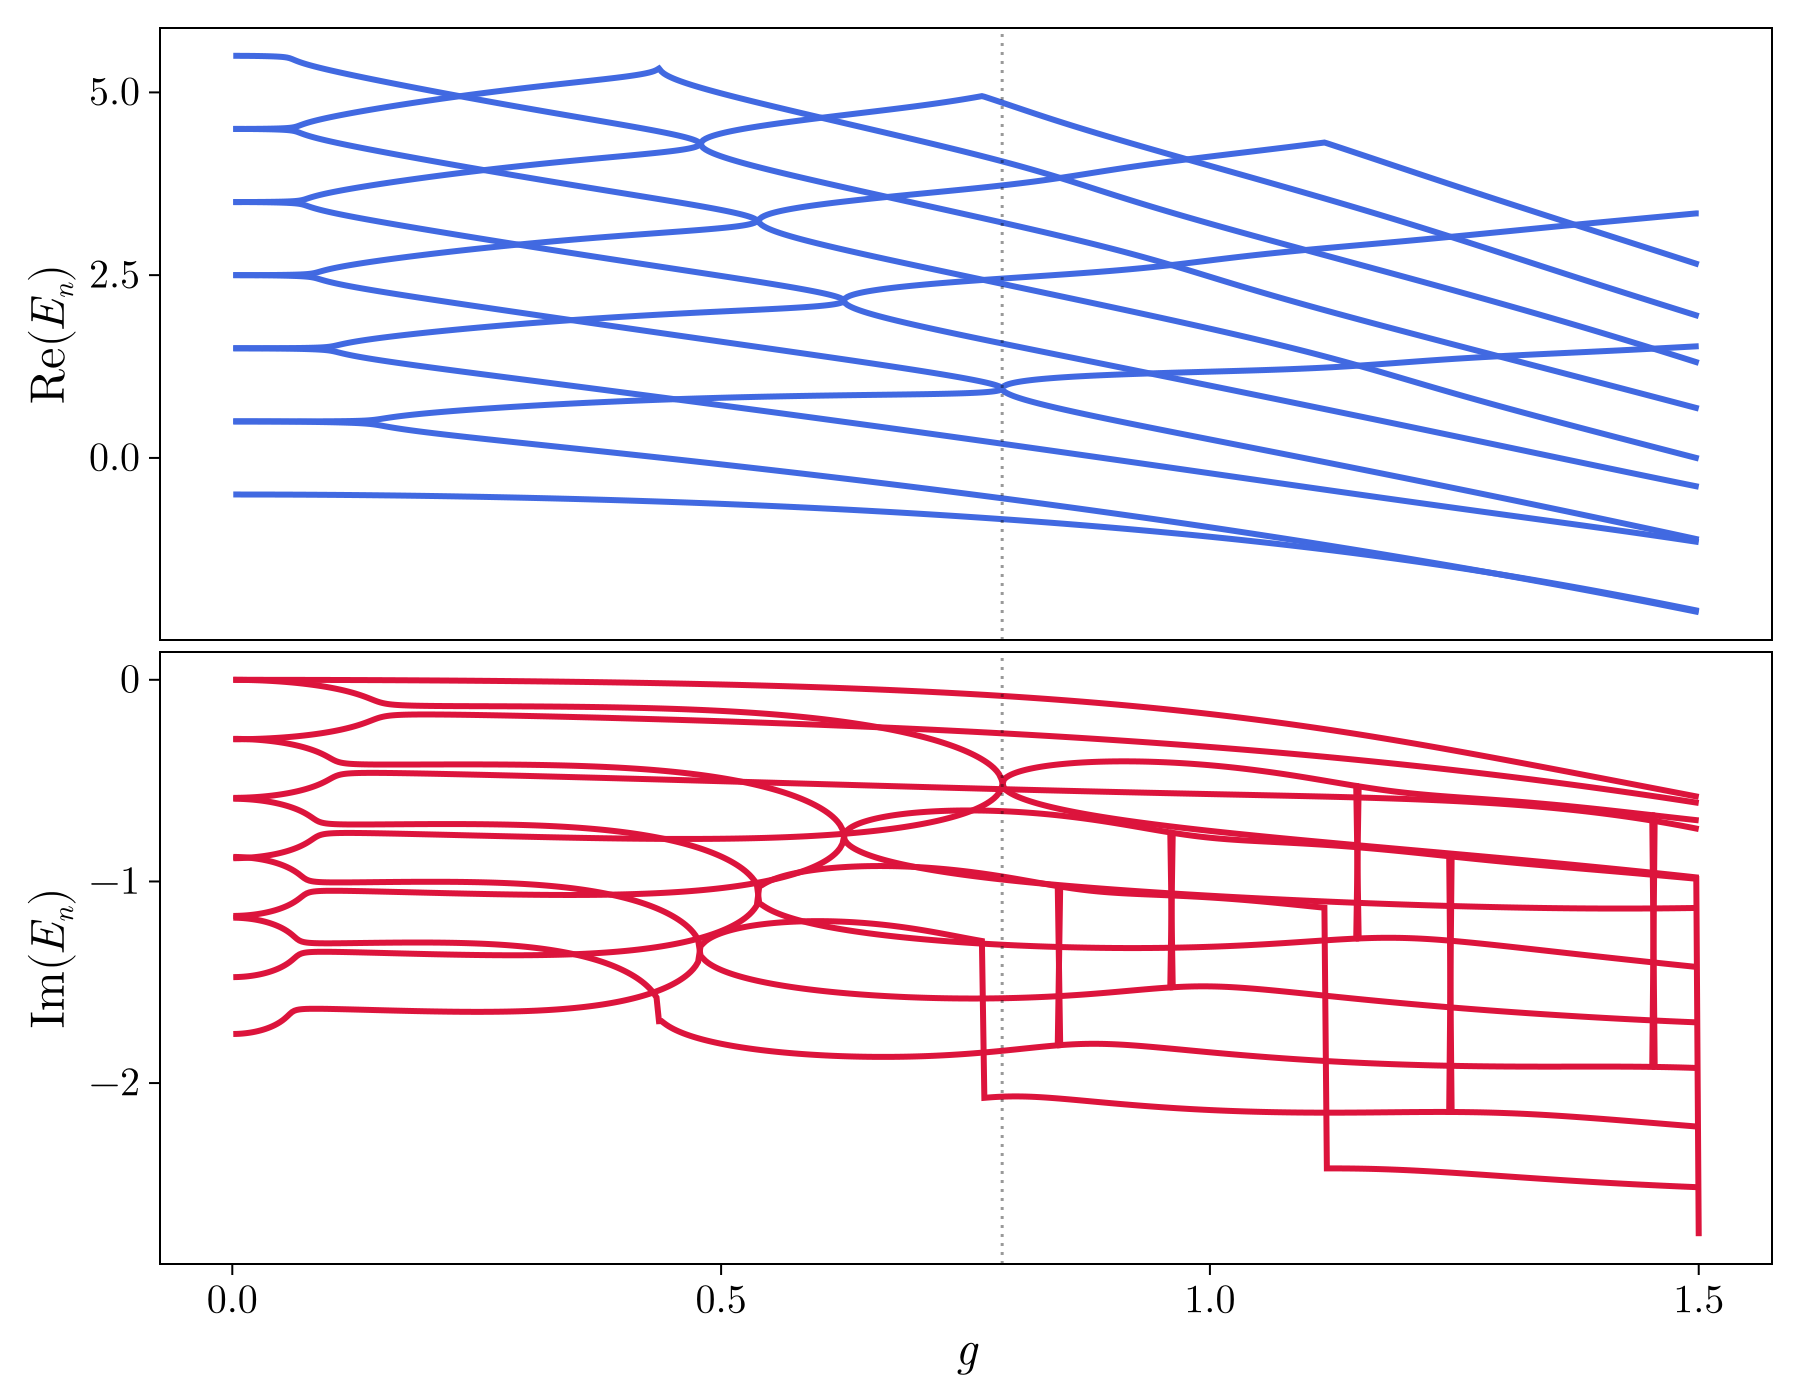

In [42]:
# Spectrum cut through one exact EP: fix all parameters except g and scan g across the EP
ep  = eps_found[8]
pep = withp(P_NH; g = ep.g, γa = ep.γa)
g_list_cut  = range(ep.g - 0.15, ep.g + 0.15, 400) |> collect
pa, pb = ep.energy_levels
kshow = 6

Ecut = fill(NaN + 0im, length(g_list), kshow)
for (i, g) in enumerate(g_list)
    v = sort(eigvals(nh_block(withp(pep; g = g), ep.parity)), by = real)
    Ecut[i, :] = v[1:kshow]
end

fig_cut = Figure(size = (900, 700))
a1 = Axis(fig_cut[1, 1]; ylabel = L"\mathrm{Re}(E_n)")
for n in 1:kshow; lines!(a1, g_list, real.(Ecut[:, n]); color = :royalblue); end
hidexdecorations!(a1; grid = false)
a2 = Axis(fig_cut[2, 1]; xlabel = L"g", ylabel = L"\mathrm{Im}(E_n)")
for n in 1:kshow; lines!(a2, g_list, imag.(Ecut[:, n]); color = :crimson); end


ep  = eps_found[12]
pep = withp(P_NH; g = ep.g, γa = ep.γa)
g_list_cut  = range(ep.g - 0.15, ep.g + 0.15, 400) |> collect
pa, pb = ep.energy_levels
kshow = 6

Ecut = fill(NaN + 0im, length(g_list), kshow)
for (i, g) in enumerate(g_list)
    v = sort(eigvals(nh_block(withp(pep; g = g), ep.parity)), by = real)
    Ecut[i, :] = v[1:kshow]
end
for n in 1:kshow; lines!(a1, g_list, real.(Ecut[:, n]); color = :royalblue); end
for n in 1:kshow; lines!(a2, g_list, imag.(Ecut[:, n]); color = :crimson); end

linkxaxes!(a1, a2)
vlines!(a1, [ep.g]; color = (:black, 0.4), linestyle = :dot)
vlines!(a2, [ep.g]; color = (:black, 0.4), linestyle = :dot)
rowgap!(fig_cut.layout, 6)

# save("spectrum_cut_EP.png", fig_cut; px_per_unit = 3)
fig_cut

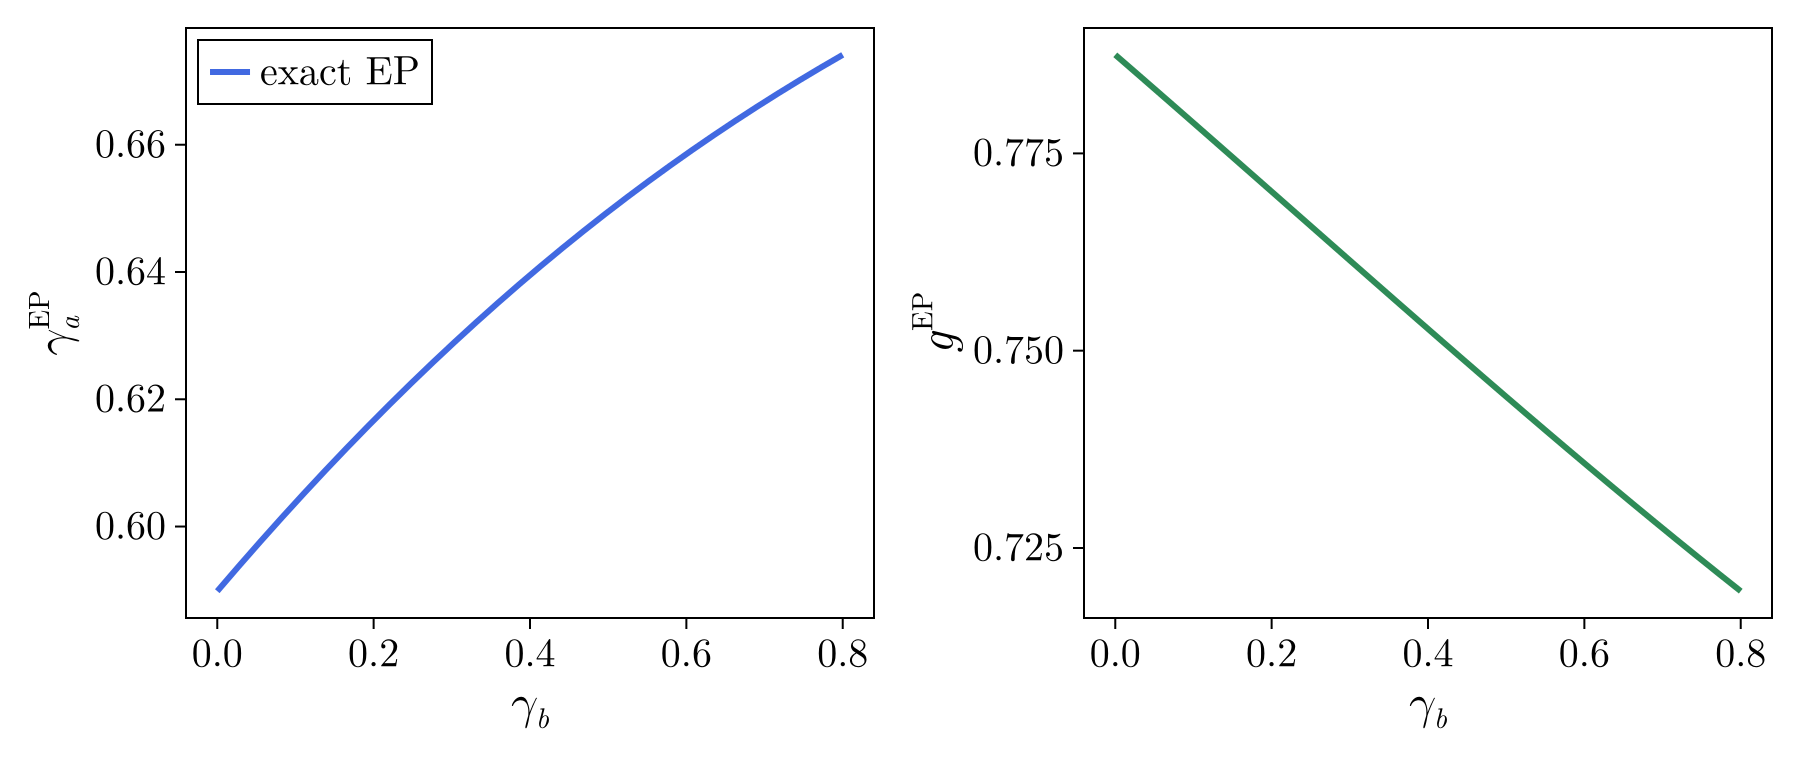

In [ ]:
# Track one exact EP while turning on the qubit loss γb (retune g and γa at each γb)
ep = eps_found[12]
pa, pb = closest_pair(withp(P_NH; g = ep.g, γa = ep.γa), ep.parity)

γb_scan = range(0.0, 0.8, 30) |> collect
gEP  = similar(γb_scan)
γaEP = similar(γb_scan)

p = withp(P_NH; g = ep.g, γa = ep.γa)
for (i, γb) in enumerate(γb_scan)
    p = newton_ep(withp(p; γb = γb), :g, :γa, ep.parity, pa, pb)
    gEP[i] = p.g; γaEP[i] = p.γa
end

fig_γb = Figure(size = (900, 380))
axa = Axis(fig_γb[1, 1]; xlabel = L"\gamma_b", ylabel = L"\gamma_a^{\mathrm{EP}}")
lines!(axa, γb_scan, γaEP; color = :royalblue, label = "exact EP")
# lines!(axa, γb_scan, γaEP[1] .+ γb_scan; color = :crimson, linestyle = :dash, label = L"\gamma_a-\gamma_b=\mathrm{cost}\ (JC)")
axislegend(axa; position = :lt)
axg = Axis(fig_γb[1, 2]; xlabel = L"\gamma_b", ylabel = L"g^{\mathrm{EP}}")
lines!(axg, γb_scan, gEP; color = :seagreen)
save("ep_vs_gammab.png", fig_γb; px_per_unit = 3)
fig_γb

g = 0.7 : exact EPs on the (γa, γb) plane = 1
  γa = 0.4142   γb = 0.0592   odd   gap = 1.1e-7


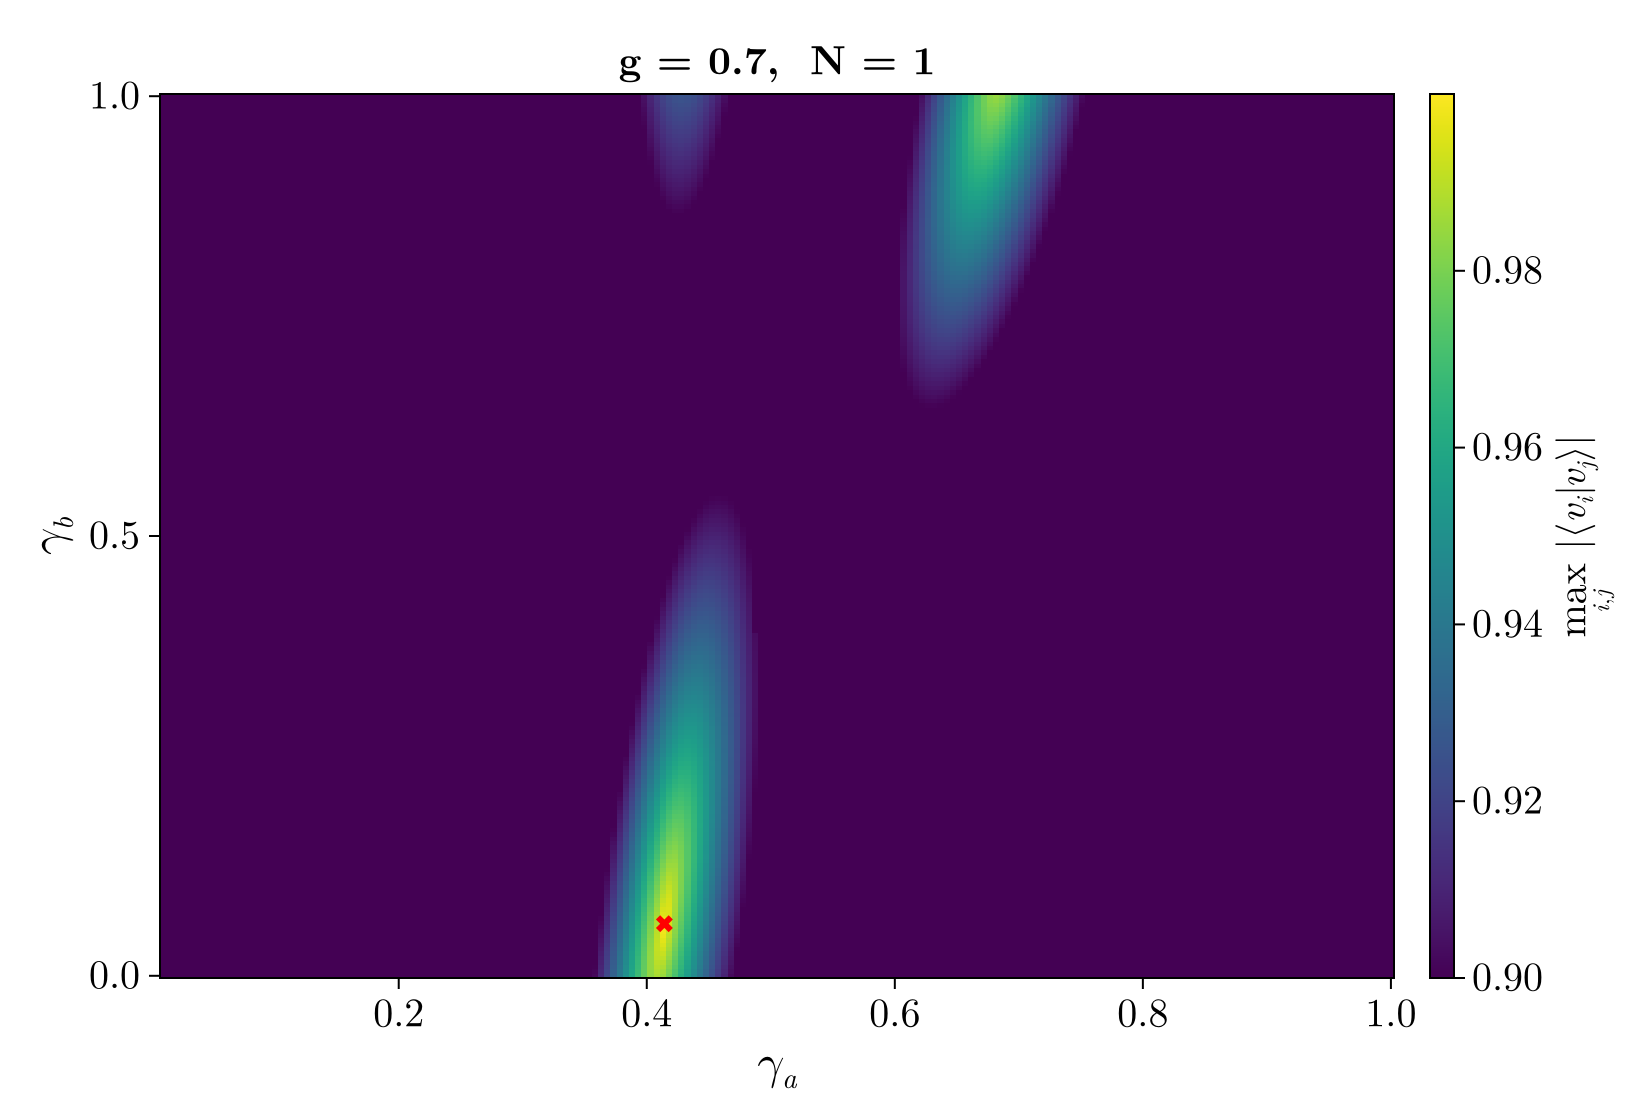

In [59]:
# Map exact EPs on the (γa, γb) plane at fixed g, tuning (:γa, :γb)
g_fix    = 0.7
γa_scan  = range(0.01, 1.0, 200) |> collect
γb_scan2 = range(0.0, 1.0, 200) |> collect

GAP2 = fill(Inf, length(γa_scan), length(γb_scan2))
OVL2 = zeros(length(γa_scan), length(γb_scan2))
PAR2 = fill(:even, length(γa_scan), length(γb_scan2))

for (i, γa) in enumerate(γa_scan), (j, γb) in enumerate(γb_scan2)
    He, Ho = parity_blocks_NH_coll(g_fix, _vars(withp(P_NH; g = g_fix, γa = γa, γb = γb)))
    me, oe = pair_gap_overlap(He)
    mo, oo = pair_gap_overlap(Ho)
    if me <= mo
        GAP2[i, j] = me
        OVL2[i, j] = oe
        PAR2[i, j] = :even
    else
        GAP2[i, j] = mo
        OVL2[i, j] = oo
        PAR2[i, j] = :odd
    end
end

eps_gab = NamedTuple[]
for i in 2:length(γa_scan)-1, j in 2:length(γb_scan2)-1
    if all(GAP2[i, j] <= GAP2[i+di, j+dj] for di in -1:1, dj in -1:1)   # 2D local minimum
        wh = PAR2[i, j]
        pseed = withp(P_NH; g = g_fix, γa = γa_scan[i], γb = γb_scan2[j])
        pa, pb = closest_pair(pseed, wh)
        pe = newton_ep(pseed, :γa, :γb, wh, pa, pb)
        gap, ov = ep_check(pe, wh, pa, pb)
        if gap < 1e-5 && ov > 1 - 1e-6 && pe.γa ≥ 0 && pe.γb ≥ 0
            e = (γa = round(pe.γa, digits = 4), γb = round(pe.γb, digits = 4), parity = wh, gap = gap, ov = ov)
            any(u -> abs(u.γa - e.γa) < 1e-2 && abs(u.γb - e.γb) < 1e-2, eps_gab) || push!(eps_gab, e)
        end
    end
end

println("g = $g_fix : exact EPs on the (γa, γb) plane = ", length(eps_gab))
foreach(e -> println("  γa = ", e.γa, "   γb = ", e.γb, "   ", e.parity, "   ", e.energy_levels, "   gap = ", round(e.gap, sigdigits = 2)), eps_gab)

fig_gab = Figure(size = (820, 560))
axm = Axis(fig_gab[1, 1]; xlabel = L"\gamma_a", ylabel = L"\gamma_b", title = "g = $g_fix,  N = $(P_NH.N)")
hmg = heatmap!(axm, γa_scan, γb_scan2, OVL2; colormap = :viridis, colorrange = (0.9, 1.0))
Colorbar(fig_gab[1, 2], hmg; label = L"\max_{i,j}\,|\langle v_i|v_j\rangle|")
scatter!(axm, [e.γa for e in eps_gab], [e.γb for e in eps_gab]; color = :red, marker = :xcross, markersize = 12)
save("ep_map_gammas.png", fig_gab; px_per_unit = 3)
fig_gab